In [32]:
# %matplotlibtplotlib widget
import warnings
import inspect
import matplotlib.pyplot as plt
import IPython.display
from cued_sf2_lab.familiarisation import load_mat_img, plot_image
import numpy as np
from typing import Tuple

<figure id="figure-5">
<div style="background-color: white">

![](figures/dwt.svg)
</div>

<figcaption style="text-align: center">

Figure 5: An $L$ level binary discrete wavelet transform.</figcaption></figure>

# 9 The Discrete Wavelet Transform (DWT)

<div class="alert alert-warning alert-block">
    
This notebook is incomplete!</div>

The final method of energy compaction that we shall investigate, is the
discrete wavelet transform. In some ways this attempts to combine the best features of
the Laplacian pyramid and the DCT:

* Like the pyramid, the DWT analyses the image at a range of different
  scales (levels) and employs symmetrical filters;

* Like the DCT, the DWT avoids any expansion in the number of coefficients.

Wavelet theory was evolved by mathematicians during the 1980's. As with the LBT, we shall not attempt to teach this theory here, just illustrate a relatively simple form of it.

Wavelets are short waveforms which are usually the impulse responses of
filters.  Wavelet transforms employ banks of bandpass filters, whose impulse
responses are scaled versions of each other, in
order to get pass-bands in different parts of the frequency spectrum.  If the
impulse response of a filter is scaled in time by a factor $a$, then the
filter frequency response is scaled by the factor $1/a$.  Typically $a = 2$
from one filter to the next, and each bandpass filter is designed to pass a
2:1 range of frequencies (one octave). We can split an image up using wavelets by a process known as a _binary wavelet tree_.

## 9.1 The binary wavelet tree


We start in 1-D with the
simplest possible pair of filters, operating on just two input samples, $x_n$
and $x_{n-1}$.  The two filter outputs, $u_n$ and $v_n$ at time $n$ are
given by:
$$
 u_n = \tfrac{1}{2} (x_n + x_{n-1}) \quad \text{and} \quad
 v_n = \tfrac{1}{2} (x_n - x_{n-1})
$$

The first filter averages adjacent samples, and so rejects the higher
frequency components of $x$, while the second filter differences these
samples, and so rejects the lower frequency components.  These filters are
known as the _analysis_ filter pair, $H_1(z) = \tfrac{1}{2} (1 + z^{-1})$
and $H_2(z) = \tfrac{1}{2} (1 - z^{-1})$.  It is clear that we can recover the
two input samples from the filter outputs using:
$$
 x_n = u_n + v_n \quad \text{and} \quad x_{n-1} = u_n - v_n
$$

Next it is important to note that we need only retain the samples of $u_n$
and $v_n$ at even values of $n$ in order to be able to recover all the
original samples of $x$.  Hence $u$ and $v$ may be decimated 2:1 and still
allow perfect reconstruction of $x$.  If $x$ is a finite length vector (e.g. a
row of image pixels), then $u$ and $v$ are each half as long as $x$, so the
total number of samples is preserved by the transformation.

A wavelet binary tree may be constructed using these filters, by using an
identical pair, $H_1$ and $H_2$, to filter the decimated lowpass signal
$u_{2n}$, to give a pair of outputs, $uu_{2n}$ and $uv_{2n}$, representing
the lower and upper halves of the first low band.  These may again be
decimated 2:1 and still permit perfect reconstruction of $u$.  This process
may be continued as often as desired: each time splitting the lowest band in
two, and decimating the sample rate of the filter outputs by 2:1.  At each
stage the bandwidth of the two lowest filters is halved, and their impulse
responses are doubled in length.  The total number of output samples remains
constant, however many stages are used.

For example, if $f_s$ is the input sample rate, a 3-stage binary tree will
split the input signal bandwidth of 0 to $f_s/2$ into the following four
bands:
$$
0 \rightarrow f_s/16; \ \ f_s/16 \rightarrow f_s/8; \ \ f_s/8 \rightarrow
f_s/4;  \ \ f_s/4 \rightarrow f_s/2.
$$

The very simple filters, given above, do not generate a filter tree with
good characteristics, since the wavelets turn out to be just a pair of
square pulses.  These generate _blocking_ artefacts when used for image
compression (in fact they are equivalent to the 2 point ($N=2$)
DCT). A better set of filters are the LeGall 5 and 3 tap pair,
given by:
$$
 u_n = \tfrac{1}{8} (-x_{n+2} + 2 x_{n+1} + 6 x_n + 2 x_{n-1} - x_{n-2})
  \quad \text{ and }  \quad
 v_{n+1} = \tfrac{1}{4} (-x_{n+2} + 2 x_{n+1} - x_n)
$$

If $u$ and $v$ are decimated by 2 by choosing even $n$ only, the lowband outputs
$u_n$ are centred on the even samples, and the highband outputs $v_{n+1}$ are
centred on the odd samples.  This is very important to allow perfect
reconstruction of $x$ from $u$ and $v$.

The equations for reconstruction may be obtained by solving the above to get:

\begin{align}
 x_n &= \tfrac{1}{2} (-v_{n+1} + 2 u_n - v_{n-1}) \quad \text{and}  \\
 x_{n+1} &= \tfrac{1}{2} (x_{n+2} + 4 v_{n+1} + x_n) =
 \tfrac{1}{4} (-v_{n+3} + 2 u_{n+2} + 6 v_{n+1} + 2 u_n - v_{n-1})
\end{align}

In general, most analysis filters will not yield such simple reconstruction
solutions, and the design of suitable filters is a non-trivial topic that we
shall not cover here.


# 9.2 Applying the DWT to images


As with the DCT, the 2-D DWT may be obtained by applying a 1-D transform to
first the rows and then the columns of an image.

Start by loading the Lighthouse image and defining the two LeGall
filters given above:

In [33]:
X, _ = load_mat_img(img='lighthouse.mat', img_info='X', cmap_info={'map', 'map2'})
X = X - 128.0
h1 = np.array([-1, 2, 6, 2, -1])/8
h2 = np.array([-1, 2, -1])/4

We can use the function `rowdec` from the pyramid work, to
produce a decimated and lowpass filtered version of the rows of
`X` (remembering to subtract 128 as before) using:

In [34]:
from cued_sf2_lab.laplacian_pyramid import rowdec
U = rowdec(X, h1)

To get the high-pass image `V`, it is important to align the decimated
samples with the odd columns of `X` (assuming the first column is $n = 0$)
whereas `U` is aligned with the even columns.  To do this we use a
slightly modified version of `rowdec`, called `rowdec2`.

In [35]:
from cued_sf2_lab.laplacian_pyramid import rowdec2
V = rowdec2(X, h2)

<div class="alert alert-block alert-danger">

Display `U` and `V` to see the outputs of the first filter pair
and comment on their relative energies (or standard deviations). Note that `U` and `V` are half the width of `X`, but that `U` is otherwise similar to `X`.</div>

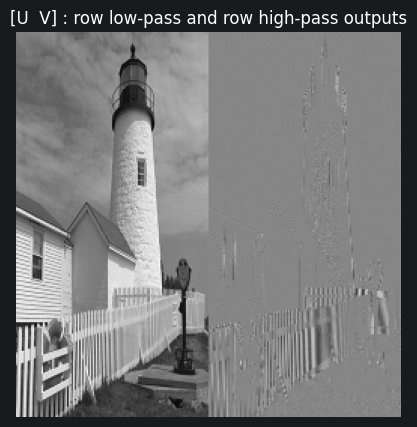

U shape: (256, 128)
V shape: (256, 128)

std(U) = 49.9033
std(V) = 10.3377

energy(U) = 8.2310e+07
energy(V) = 3.5018e+06
energy ratio U/V = 23.50


In [36]:
import numpy as np
import matplotlib.pyplot as plt

from cued_sf2_lab.familiarisation import load_mat_img
from cued_sf2_lab.laplacian_pyramid import rowdec, rowdec2

# Load Lighthouse image
X, cmaps_dict = load_mat_img(
    img='lighthouse.mat',
    img_info='X',
    cmap_info={'map', 'map2'}
)

# Subtract 128 as in previous transform sections
X = X - 128.0

# LeGall analysis filters
h1 = np.array([-1, 2, 6, 2, -1]) / 8.0  # low-pass filter
h2 = np.array([-1, 2, -1]) / 4.0  # high-pass filter

# Row filtering and decimation
U = rowdec(X, h1)  # low-pass row subband, even alignment
V = rowdec2(X, h2)  # high-pass row subband, odd alignment

# Display side by side
plt.figure(figsize=(12, 5))
plt.imshow(np.hstack((U, V)), cmap='gray')
plt.title("[U  V] : row low-pass and row high-pass outputs")
plt.axis("off")
plt.show()

# Compare energies / standard deviations
print(f"U shape: {U.shape}")
print(f"V shape: {V.shape}")
print()
print(f"std(U) = {np.std(U):.4f}")
print(f"std(V) = {np.std(V):.4f}")
print()
print(f"energy(U) = {np.sum(U ** 2):.4e}")
print(f"energy(V) = {np.sum(V ** 2):.4e}")
print(f"energy ratio U/V = {np.sum(U ** 2) / np.sum(V ** 2):.2f}")

Now filter the columns of `U` and `V` using `rowdec
/ rowdec2` with the transpose operator:

In [37]:
UU = rowdec(U.T, h1).T
UV = rowdec2(U.T, h2).T
VU = rowdec(V.T, h1).T
VV = rowdec2(V.T, h2).T

<div class="alert alert-block alert-danger">
    
Display `np.block([[UU, VU], [UV, VV]])`, and comment
on what sort of edges or features are selected by each filter. You may need to multiply the high-pass images by a factor $k > 1$ to display them clearly. Why is this?</div>

UU shape: (128, 128)
UV shape: (128, 128)
VU shape: (128, 128)
VV shape: (128, 128)

std(UU) = 49.7047
std(UV) = 8.2666
std(VU) = 10.2490
std(VV) = 2.4245

energy(UU) = 4.0847e+07
energy(UV) = 1.1196e+06
energy(VU) = 1.7210e+06
energy(VV) = 9.6318e+04


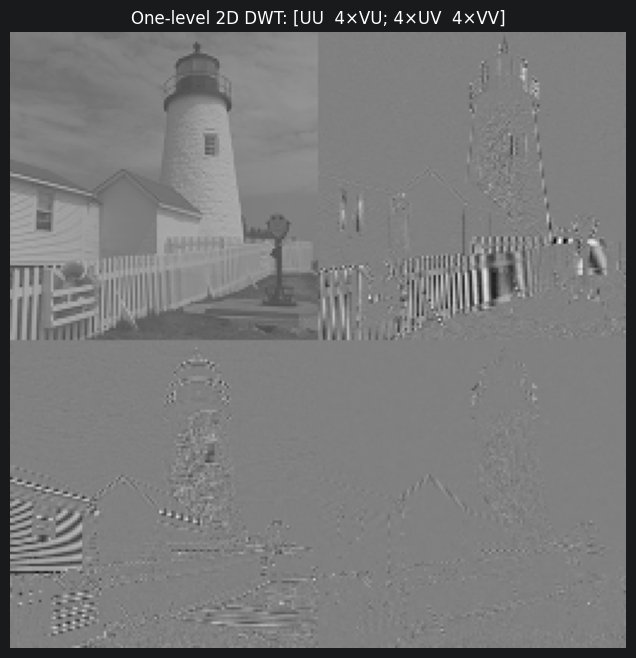

In [38]:
# Apply the same LeGall filters down the columns of U and V.
# We do this by transposing, applying rowdec / rowdec2, then transposing back.

UU = rowdec(U.T, h1).T  # low-pass rows, low-pass columns
UV = rowdec2(U.T, h2).T  # low-pass rows, high-pass columns

VU = rowdec(V.T, h1).T  # high-pass rows, low-pass columns
VV = rowdec2(V.T, h2).T  # high-pass rows, high-pass columns

print(f"UU shape: {UU.shape}")
print(f"UV shape: {UV.shape}")
print(f"VU shape: {VU.shape}")
print(f"VV shape: {VV.shape}")

print()
print(f"std(UU) = {np.std(UU):.4f}")
print(f"std(UV) = {np.std(UV):.4f}")
print(f"std(VU) = {np.std(VU):.4f}")
print(f"std(VV) = {np.std(VV):.4f}")

print()
print(f"energy(UU) = {np.sum(UU ** 2):.4e}")
print(f"energy(UV) = {np.sum(UV ** 2):.4e}")
print(f"energy(VU) = {np.sum(VU ** 2):.4e}")
print(f"energy(VV) = {np.sum(VV ** 2):.4e}")

# High-pass subbands are much lower amplitude, so scale them for display
k = 4

display_dwt = np.block([
    [UU, k * VU],
    [k * UV, k * VV]
])

plt.figure(figsize=(8, 8))
plt.imshow(display_dwt, cmap="gray")
plt.title(f"One-level 2D DWT: [UU  {k}×VU; {k}×UV  {k}×VV]")
plt.axis("off")
plt.show()

We must now check that it is possible to recover the image from
these sub-images, using reconstruction filters, `g1` and `g2`, and the functions, `rowint` and `rowint` (which
is modified in a similar way to `rowdec2` to allow correct
alignment of the high-pass samples). To reconstruct `Ur` and
`Vr` from `UU`, `UV`, `VU` and `VV` use:

In [39]:
from cued_sf2_lab.laplacian_pyramid import rowint, rowint2

g1 = np.array([1, 2, 1])/2
g2 = np.array([-1, -2, 6, -2, -1])/4
Ur = rowint(UU.T, g1).T + rowint2(UV.T, g2).T
Vr = rowint(VU.T, g1).T + rowint2(VV.T, g2).T

Note the gain of 2 in the reconstruction filters, `g1` and
`g2` (to compensate for losing half the samples in the
decimation / interpolation processes).   These filters are also
not quite the same as those that might be inferred from the
equations for $x_n$ and $x_{n+1}$ on the previous page.  This is
because `g1` defines how {\it only} the $u$ samples contribute
both to the even and odd samples of $x$, while `g2` defines
how the $v$ samples contribute.

Check that `Ur` and `Vr` are the same as `U` and
`V`, and then reconstruct `Xr` from these:

max abs error U - Ur = 0.0000e+00
max abs error V - Vr = 0.0000e+00
RMS error U - Ur = 0.0000e+00
RMS error V - Vr = 0.0000e+00

np.allclose(U, Ur) = True
np.allclose(V, Vr) = True


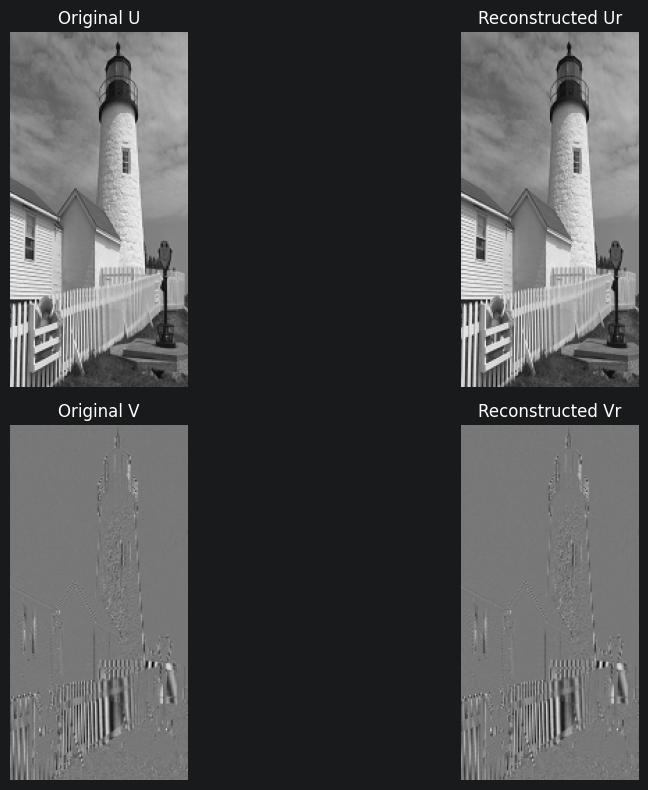

In [40]:
# Reconstruction filters for the LeGall wavelet
g1 = np.array([1, 2, 1]) / 2.0
g2 = np.array([-1, -2, 6, -2, -1]) / 4.0

# Reconstruct U and V from the four subbands
Ur = rowint(UU.T, g1).T + rowint2(UV.T, g2).T
Vr = rowint(VU.T, g1).T + rowint2(VV.T, g2).T

# Check that Ur and Vr match U and V
U_error = U - Ur
V_error = V - Vr

print(f"max abs error U - Ur = {np.max(np.abs(U_error)):.4e}")
print(f"max abs error V - Vr = {np.max(np.abs(V_error)):.4e}")
print(f"RMS error U - Ur = {np.std(U_error):.4e}")
print(f"RMS error V - Vr = {np.std(V_error):.4e}")

print()
print(f"np.allclose(U, Ur) = {np.allclose(U, Ur)}")
print(f"np.allclose(V, Vr) = {np.allclose(V, Vr)}")

# Display original and reconstructed row-filter outputs
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(U, cmap="gray")
plt.title("Original U")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(Ur, cmap="gray")
plt.title("Reconstructed Ur")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(V, cmap="gray")
plt.title("Original V")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(Vr, cmap="gray")
plt.title("Reconstructed Vr")
plt.axis("off")

plt.tight_layout()
plt.show()

In [41]:
# demonstrator answer here
np.testing.assert_equal(Ur, U)
np.testing.assert_equal(Vr, V)

In [42]:
Xr = rowint(Ur,g1) + rowint2(Vr,g2)

Check that `Xr` is the same as `X`.

max abs error X - Xr = 0.0000e+00
RMS error X - Xr = 0.0000e+00
np.allclose(X, Xr) = True


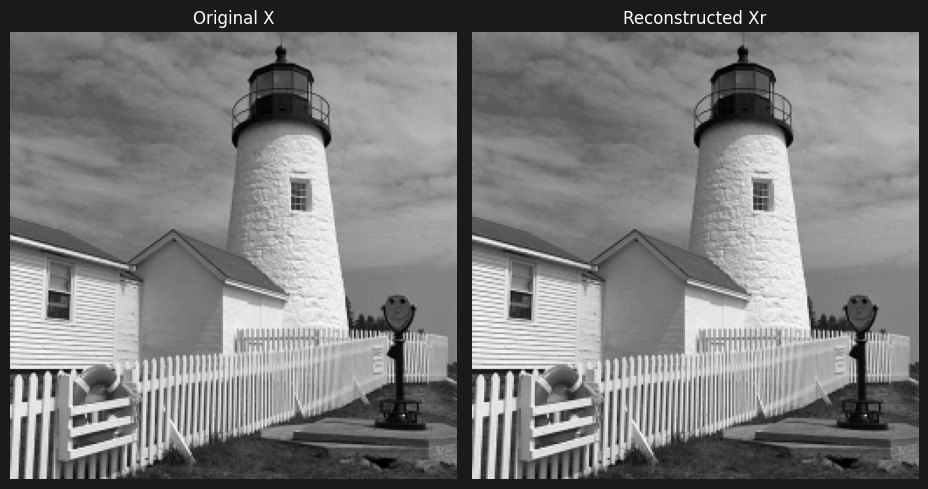

In [43]:
# Reconstruct the original image from Ur and Vr
Xr = rowint(Ur, g1) + rowint2(Vr, g2)

# Check reconstruction error
X_error = X - Xr

print(f"max abs error X - Xr = {np.max(np.abs(X_error)):.4e}")
print(f"RMS error X - Xr = {np.std(X_error):.4e}")
print(f"np.allclose(X, Xr) = {np.allclose(X, Xr)}")

# Display original, reconstructed, and error image
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(X, cmap="gray")
plt.title("Original X")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Xr, cmap="gray")
plt.title("Reconstructed Xr")
plt.axis("off")

plt.tight_layout()
plt.show()

The above operations are a bit tedious to repeat if we want to
apply the DWT recursively to obtain several levels of filtering,
so we have written a pair of functions, `dwt` and `idwt`, to perform the 2-D analysis and reconstruction
operations. Examine these to see that they perform the same
operations as above, except that the transformed sub-images are
stored as parts of a single matrix, the same size as `X`,
rather than as separate matrices.

In [44]:
from cued_sf2_lab.dwt import dwt
IPython.display.Code(inspect.getsource(dwt), language="python")

def dwt(X: np.ndarray, h1: np.ndarray = h1, h2: np.ndarray = h2) -> np.ndarray:
    """
    Return a 1-level 2-D discrete wavelet transform of X.

    Default h1 and h2 are the LeGall filter pair.

    Parameters:
        X: Image matrix (Usually 256x256)
        h1, h2: Filter coefficients
    Returns:
        Y: 1-level 2D DWT of X
    """
    m, n = X.shape
    if m % 2 or n % 2:
        raise ValueError("Image dimensions must be even")
    Y = np.concatenate([rowdec(X, h1), rowdec2(X, h2)], axis=1)
    Y = np.concatenate([rowdec(Y.T, h1).T, rowdec2(Y.T, h2).T], axis=0)
    return Y

In [45]:
from cued_sf2_lab.dwt import idwt
IPython.display.Code(inspect.getsource(idwt), language="python")

def idwt(X: np.ndarray, g1: np.ndarray = g1, g2: np.ndarray = g2)-> np.ndarray:
    """
    Return a 1-level 2-D inverse discrete wavelet transform on X.

    If filters G1 and G2 are given, then they are used, otherwise the LeGall
    filter pair are used.
    """
    m, n = X.shape
    if m % 2 or n % 2:
        raise ValueError("Image dimensions must be even")
    m2 = m//2
    n2 = n//2
    Y = rowint(X[:m2, :].T, g1).T + rowint2(X[m2:, :].T,g2).T;
    Y = rowint(Y[:, :n2], g1) + rowint2(Y[:, n2:], g2)
    return Y

You can check their operation as below::

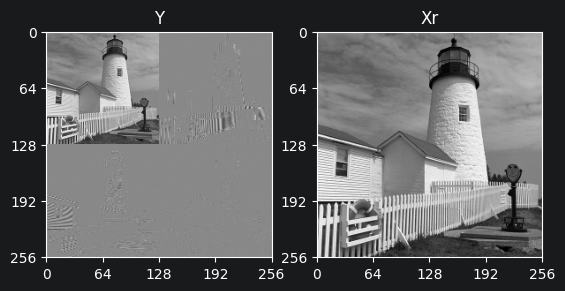

In [46]:
Y = dwt(X)
Xr = idwt(Y)

fig, axs = plt.subplots(1, 2)
plot_image(Y, ax=axs[0])
axs[0].set(title="Y")
plot_image(Xr, ax=axs[1])
axs[1].set(title="Xr");

`Y` should be the same as the composite `[UU VU; UV VV]` image that
you displayed earlier, and `Xr` should be the same as `X`.

Now implement a multilevel DWT by first applying `dwt` to
`X` using:

```python
m=256
Y=dwt(X)
plot_image(Y, ax=some_axis)
```

and then iteratively apply `dwt` to the top left sub-image
of `Y` by repeating:
```python
m = m//2
Y[:m,:m] = dwt(Y[:m,:m])
plot_image(Y, ax=some_axis)
```

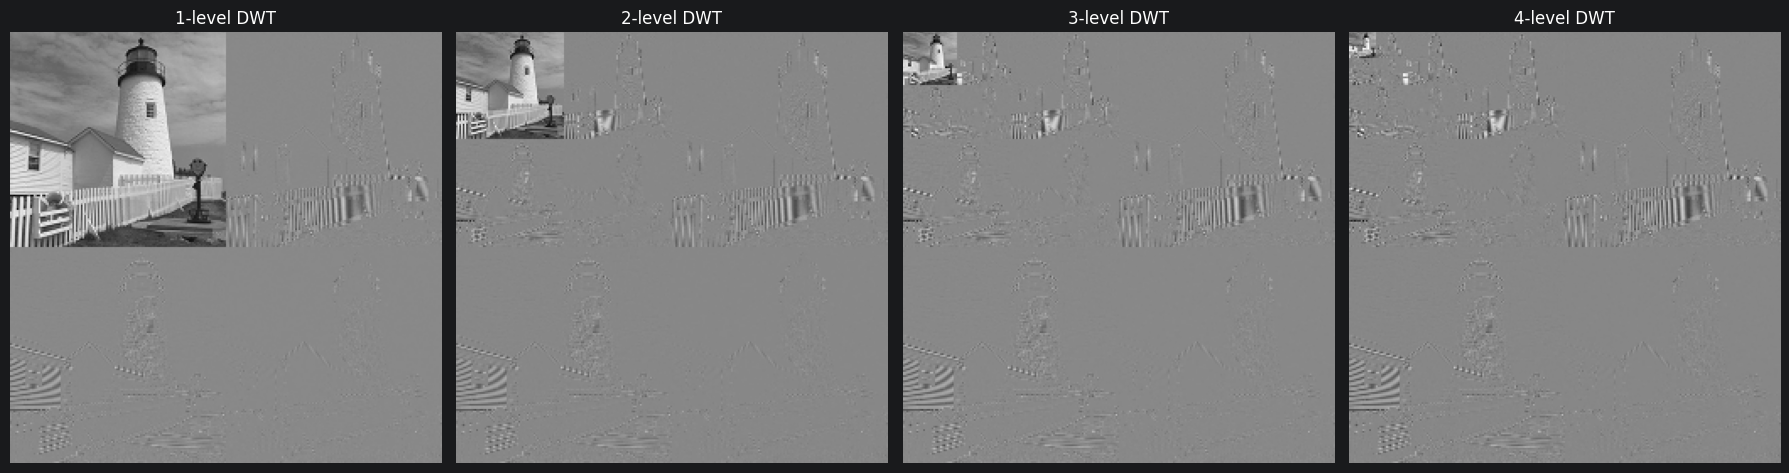

In [47]:

# First apply one-level DWT to the whole image
m = 256
Y = dwt(X)

# Display each stage of the multilevel decomposition
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

plot_image(Y, ax=axes[0])
axes[0].set_title("1-level DWT")
axes[0].axis("off")

# Repeatedly apply DWT to the top-left low-pass subimage
for level in range(2, 5):
    m = m // 2
    Y[:m, :m] = dwt(Y[:m, :m])

    plot_image(Y, ax=axes[level - 1])
    axes[level - 1].set_title(f"{level}-level DWT")
    axes[level - 1].axis("off")

plt.tight_layout()
plt.show()

We now have the image split using a binary wavelet tree (stricly a
quaternary tree in 2-D).  Write
similar iterative code to that given above, which can reconstruct
the image from the final set of `Y` sub-images after a 4-level
wavelet transform. Check that your reconstructed image is the
same as `X`.

Multilevel reconstruction
X shape: (256, 256)
Y shape: (256, 256)
max abs error X - Xr = 0.0000e+00
RMS error X - Xr     = 0.0000e+00
np.allclose(X, Xr)   = True


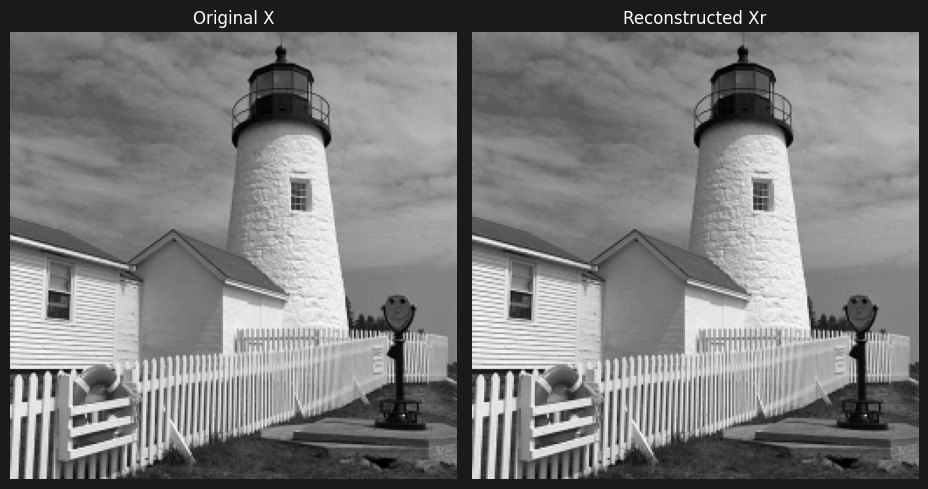

In [48]:
levels = 4  # use the same number of DWT levels you created earlier
Yr = Y.copy()

# Smallest transformed low-pass block size
m = X.shape[0] // (2 ** levels)

for level in range(levels, 0, -1):
    Yr[:2 * m, :2 * m] = idwt(Yr[:2 * m, :2 * m])
    m = m * 2

Xr = Yr

err = X - Xr

print("Multilevel reconstruction")
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"max abs error X - Xr = {np.max(np.abs(err)):.4e}")
print(f"RMS error X - Xr     = {np.std(err):.4e}")
print(f"np.allclose(X, Xr)   = {np.allclose(X, Xr)}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(X, cmap="gray")
plt.title("Original X")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Xr, cmap="gray")
plt.title("Reconstructed Xr")
plt.axis("off")

plt.tight_layout()
plt.show()

## 9.3 Quantisation and coding efficiency

First rewrite the sequences of operations required to perform
$n$ levels of DWT and inverse DWT as two separate M-files, `nlevdwt` and `nlevidwt`. `nlevdwt` should transform
`X` into `Y`, and `nlevidwt` should inverse
transform a quantised set of sub-images `Yq` into the
reconstructed image `Z`.  Check your functions by ensuring
that `Z` is the same as `X` if `Yq = Y`.

In [49]:
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt


def nlevdwt(X: np.ndarray, n: int) -> np.ndarray:
    """
    Perform an n-level 2-D DWT.

    The first DWT is applied to the whole image.
    Each later DWT is applied only to the top-left low-pass sub-image.
    """
    Y = X.copy()

    rows, cols = Y.shape

    for level in range(n):
        r = rows // (2 ** level)
        c = cols // (2 ** level)

        Y[:r, :c] = dwt(Y[:r, :c])

    return Y


def nlevidwt(Yq: np.ndarray, n: int) -> np.ndarray:
    """
    Perform an n-level inverse 2-D DWT.

    Yq is a possibly quantised n-level DWT image.
    """
    Z = Yq.copy()

    rows, cols = Z.shape

    for level in range(n - 1, -1, -1):
        r = rows // (2 ** level)
        c = cols // (2 ** level)

        Z[:r, :c] = idwt(Z[:r, :c])

    return Z

n = 4
max abs error X - Z = 0.0000e+00
RMS error X - Z     = 0.0000e+00
np.allclose(X, Z)   = True


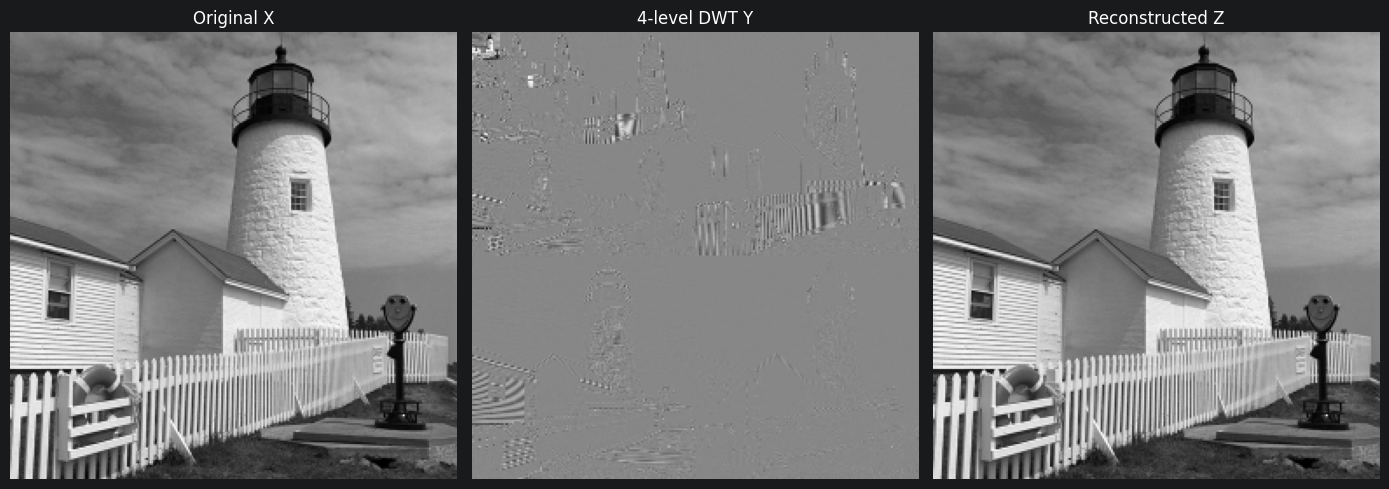

In [50]:
n = 4

Y = nlevdwt(X, n)

# Check perfect reconstruction with no quantisation
Yq = Y.copy()
Z = nlevidwt(Yq, n)

err = X - Z

print(f"n = {n}")
print(f"max abs error X - Z = {np.max(np.abs(err)):.4e}")
print(f"RMS error X - Z     = {np.std(err):.4e}")
print(f"np.allclose(X, Z)   = {np.allclose(X, Z)}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(X, cmap="gray")
plt.title("Original X")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Y, cmap="gray")
plt.title("4-level DWT Y")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Z, cmap="gray")
plt.title("Reconstructed Z")
plt.axis("off")

plt.tight_layout()
plt.show()

Now design a function, `quantdwt`, which will quantise the
sub-images of `Y` to give `Yq` and calculate their
entropy.  The sub-images at each level `i` of the DWT should
be quantised according to a $3 \times (n+1)$ matrix `dwtstep[k,i]` of
step-sizes, where $\mathtt{k}=\left\{0,1,2\right\}$ corresponds to each of the three high-pass images at level `i` (top right, bottom left, and bottom right, respectively), and the final low-pass image is quantised with `dwtstep[0,n]`. This matrix will be populated either with the same number in all elements (for equal-step-size quantisation) or a range of different numbers (for equal-MSE quantisation). The entropies for each sub-image should be stored in a similar $3 \times (n+1)$ matrix `dwtent[k,i]`.

In [51]:
from cued_sf2_lab.laplacian_pyramid import quantise, bpp


def quantdwt(Y: np.ndarray, dwtstep: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Quantise an n-level DWT image and calculate the entropy of each sub-image.

    Parameters
    ----------
    Y:
        n-level DWT image produced by nlevdwt(X, n).

    dwtstep:
        Array of shape (3, n+1).

        dwtstep[0, i] quantises the top-right high-pass sub-image at level i.
        dwtstep[1, i] quantises the bottom-left high-pass sub-image at level i.
        dwtstep[2, i] quantises the bottom-right high-pass sub-image at level i.

        The final low-pass sub-image is quantised using dwtstep[0, n].

    Returns
    -------
    Yq:
        Quantised DWT image.

    dwtent:
        Array of shape (3, n+1), containing entropy values for each sub-image.
    """
    Yq = Y.copy()
    dwtent = np.zeros_like(dwtstep, dtype=float)

    n = dwtstep.shape[1] - 1

    rows, cols = Y.shape

    for level in range(n):
        r = rows // (2 ** level)
        c = cols // (2 ** level)

        r2 = r // 2
        c2 = c // 2

        # Top-right high-pass sub-image
        sub = Y[:r2, c2:c]
        Yq[:r2, c2:c] = quantise(sub, dwtstep[0, level])
        dwtent[0, level] = bpp(Yq[:r2, c2:c])

        # Bottom-left high-pass sub-image
        sub = Y[r2:r, :c2]
        Yq[r2:r, :c2] = quantise(sub, dwtstep[1, level])
        dwtent[1, level] = bpp(Yq[r2:r, :c2])

        # Bottom-right high-pass sub-image
        sub = Y[r2:r, c2:c]
        Yq[r2:r, c2:c] = quantise(sub, dwtstep[2, level])
        dwtent[2, level] = bpp(Yq[r2:r, c2:c])

    # Final low-pass sub-image
    r_lp = rows // (2 ** n)
    c_lp = cols // (2 ** n)

    Yq[:r_lp, :c_lp] = quantise(Y[:r_lp, :c_lp], dwtstep[0, n])
    dwtent[0, n] = bpp(Yq[:r_lp, :c_lp])

    return Yq, dwtent

Using these functions, for a given number of levels $n$ (typically
between 3 and 5), you should generate `Y`, quantise it to
give `Yq` and reconstruct `Z` from `Yq`.

DWT entropy matrix:
[[0.91278689 1.06763722 1.14458482 1.35167841 3.37736165]
 [0.80317283 1.06184434 1.37365956 1.63717336 0.        ]
 [0.14154013 0.31992385 0.62362184 0.70253722 0.        ]]
RMS error after quantisation = 10.1353


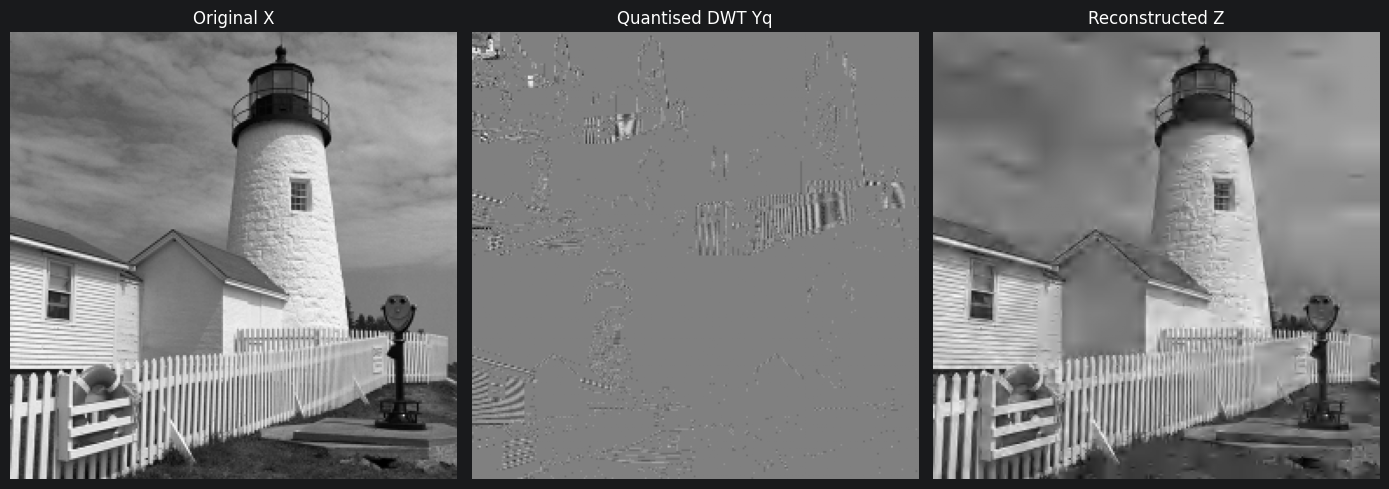

In [52]:
n = 4
step = 17

Y = nlevdwt(X, n)

dwtstep = step * np.ones((3, n + 1))

Yq, dwtent = quantdwt(Y, dwtstep)
Z = nlevidwt(Yq, n)

err = X - Z

print("DWT entropy matrix:")
print(dwtent)

print(f"RMS error after quantisation = {np.std(err):.4f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(X, cmap="gray")
plt.title("Original X")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Yq, cmap="gray")
plt.title("Quantised DWT Yq")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Z, cmap="gray")
plt.title("Reconstructed Z")
plt.axis("off")

plt.tight_layout()
plt.show()

All of our experiments thus far have been performed on only one image. At this stage it is worth starting to experiment with the additional `Bridge` image, as well as Lighthouse. Bridge contains a lot more fine detail and may not lead to the same conclusions regarding performance.

In [53]:
Xb, _ = load_mat_img(img='bridge.mat', img_info='X', cmap_info={'map'})
Xb = Xb - 128.0

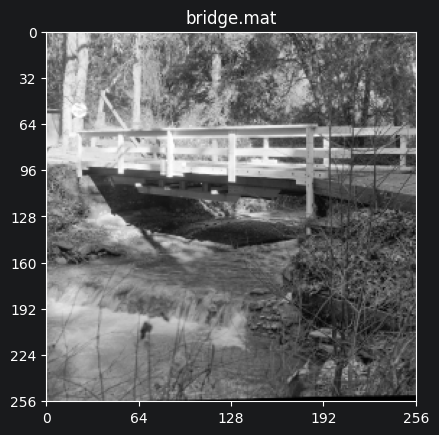

In [54]:
fig, ax = plt.subplots()
plot_image(Xb, ax=ax)
ax.set(title="bridge.mat");


<div class="alert alert-block alert-danger">

Investigate the performance of
both an equal-step-size and an equal-MSE scheme (follow a similar procedure as you used for the Laplacian Pyramid to find the appropriate step-size ratios). Hence determine how many levels of DWT are reasonably optimal for the Lighthouse and Bridge images. Also evaluate the subjective quality of your reconstructed images, and comment on how this depends on $n$ and on the way that step-sizes are assigned
to the different levels. Once again, for each image choose quantisation steps such that you match the rms error to that for direct quantisation with a step-size of 17.</div>


Image: Lighthouse
Direct quantisation step = 17.0
Target RMS error         = 4.8612
Direct total bits        = 228119.0

Testing n = 1
  Equal-step: step = 12.252, RMS = 4.8747, bits = 104575.8, CR = 2.181
  Equal-MSE:  scale = 14.876, RMS = 4.8507, bits = 107241.2, CR = 2.127

Testing n = 2
  Equal-step: step = 9.379, RMS = 4.8683, bits = 82236.1, CR = 2.774
  Equal-MSE:  scale = 9.004, RMS = 4.8479, bits = 80110.0, CR = 2.848

Testing n = 3
  Equal-step: step = 7.625, RMS = 4.8580, bits = 84912.0, CR = 2.687
  Equal-MSE:  scale = 4.660, RMS = 4.8700, bits = 74805.7, CR = 3.049

Testing n = 4
  Equal-step: step = 6.564, RMS = 4.8610, bits = 91755.9, CR = 2.486
  Equal-MSE:  scale = 2.348, RMS = 4.8776, bits = 73808.1, CR = 3.091

Image: Bridge
Direct quantisation step = 17.0
Target RMS error         = 4.9223
Direct total bits        = 237050.7

Testing n = 1
  Equal-step: step = 8.817, RMS = 4.9170, bits = 143249.0, CR = 1.655
  Equal-MSE:  scale = 12.127, RMS = 4.9054, bits = 141977

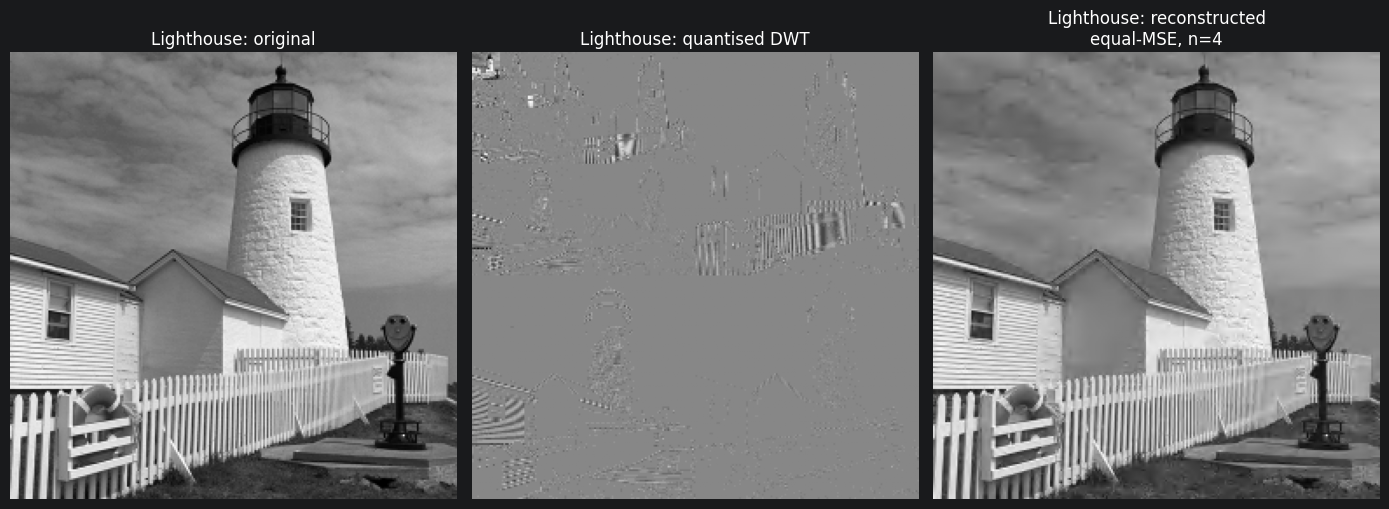


Best result for Bridge
Scheme: equal-MSE
n: 4
RMS error: 4.9087
Bits: 123946.1
Compression ratio: 1.913
DWT step matrix:
[[8.772764   5.72095641 3.11988608 1.59729155 1.70460937]
 [8.772764   5.72095641 3.11988608 1.59729155 0.        ]
 [6.33670007 4.94047802 2.87180496 1.49673018 0.        ]]


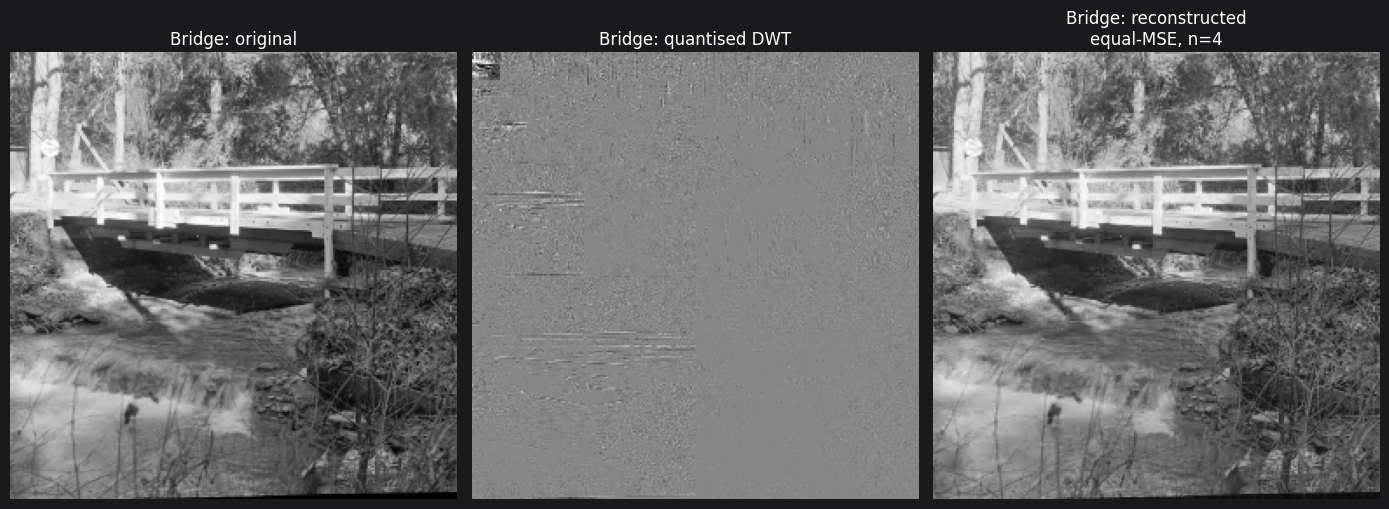

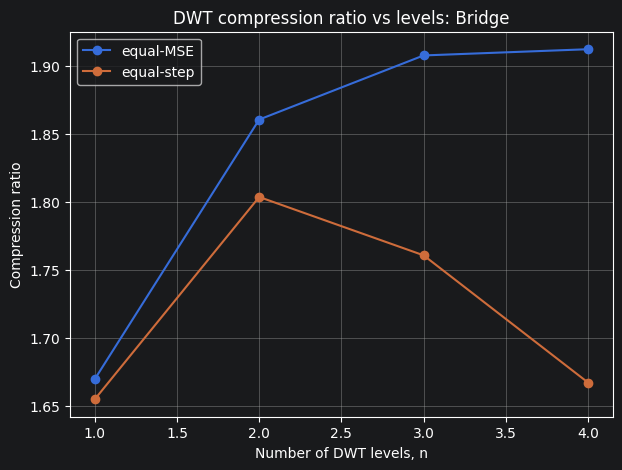

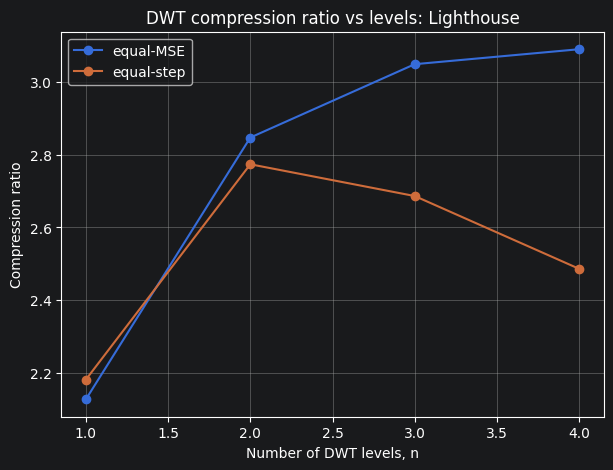

In [55]:
def direct_quantisation_reference(X: np.ndarray, step: float = 17.0):
    Xq = quantise(X, step)
    rms = np.std(X - Xq)
    bits = bpp(Xq) * X.size
    return Xq, rms, bits

def dwt_bits(dwtent: np.ndarray, image_shape: tuple, n: int) -> float:
    rows, cols = image_shape
    total_bits = 0.0

    # High-pass bands
    for level in range(n):
        band_rows = rows // (2 ** (level + 1))
        band_cols = cols // (2 ** (level + 1))
        band_pixels = band_rows * band_cols

        total_bits += dwtent[0, level] * band_pixels
        total_bits += dwtent[1, level] * band_pixels
        total_bits += dwtent[2, level] * band_pixels

    # Final low-pass band
    lp_rows = rows // (2 ** n)
    lp_cols = cols // (2 ** n)
    lp_pixels = lp_rows * lp_cols

    total_bits += dwtent[0, n] * lp_pixels

    return total_bits

def make_equal_step_matrix(n: int, step: float) -> np.ndarray:
    return step * np.ones((3, n + 1))

def dwt_subband_slices(shape: tuple, n: int):
    rows, cols = shape
    bands = []

    for level in range(n):
        r = rows // (2 ** level)
        c = cols // (2 ** level)

        r2 = r // 2
        c2 = c // 2

        # Top-right high-pass
        bands.append((0, level, slice(0, r2), slice(c2, c), f"HL_{level+1}"))

        # Bottom-left high-pass
        bands.append((1, level, slice(r2, r), slice(0, c2), f"LH_{level+1}"))

        # Bottom-right high-pass
        bands.append((2, level, slice(r2, r), slice(c2, c), f"HH_{level+1}"))

    # Final low-pass
    r_lp = rows // (2 ** n)
    c_lp = cols // (2 ** n)

    bands.append((0, n, slice(0, r_lp), slice(0, c_lp), f"LL_{n}"))

    return bands

def dwt_equal_mse_ratios(image_shape: tuple, n: int, impulse_amp: float = 100.0) -> np.ndarray:
    ratios = np.zeros((3, n + 1), dtype=float)
    energies = np.zeros((3, n + 1), dtype=float)

    for k, level, rs, cs, name in dwt_subband_slices(image_shape, n):
        Yimp = np.zeros(image_shape, dtype=float)

        # Put impulse at centre of this subband
        r_mid = (rs.start + rs.stop) // 2
        c_mid = (cs.start + cs.stop) // 2

        Yimp[r_mid, c_mid] = impulse_amp

        Zimp = nlevidwt(Yimp, n)

        energy = np.sum(Zimp ** 2)
        energies[k, level] = energy

        ratios[k, level] = 1.0 / np.sqrt(energy)

    # Normalise so that the final low-pass ratio is 1
    ratios = ratios / ratios[0, n]

    return ratios, energies

def optimise_dwt_scale_to_rms(
    X: np.ndarray,
    n: int,
    ratios: np.ndarray,
    target_rms: float,
    tol: float = 0.02,
    max_iter: int = 40,
):
    Y = nlevdwt(X, n)

    def rms_for_alpha(alpha):
        dwtstep = alpha * ratios
        Yq, dwtent = quantdwt(Y, dwtstep)
        Z = nlevidwt(Yq, n)
        rms = np.std(X - Z)
        bits = dwt_bits(dwtent, X.shape, n)
        return rms, bits, Z, Yq, dwtent, dwtstep

    # Bracket the solution
    lo = 0.01
    hi = 1.0

    rms_hi, *_ = rms_for_alpha(hi)

    while rms_hi < target_rms:
        hi *= 2.0
        rms_hi, *_ = rms_for_alpha(hi)

        if hi > 10000:
            raise RuntimeError("Could not bracket target RMS error.")

    # Binary search
    best = None

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)

        rms, bits, Z, Yq, dwtent, dwtstep = rms_for_alpha(mid)

        best = {
            "n": n,
            "alpha": mid,
            "rms": rms,
            "bits": bits,
            "Z": Z,
            "Yq": Yq,
            "dwtent": dwtent,
            "dwtstep": dwtstep,
        }

        if abs(rms - target_rms) < tol:
            break

        if rms < target_rms:
            lo = mid
        else:
            hi = mid

    return best

def investigate_dwt_image(
    X: np.ndarray,
    image_name: str,
    levels=(1,2, 3, 4),
    direct_step: float = 17.0,
):
    Xq_direct, target_rms, direct_bits = direct_quantisation_reference(X, direct_step)

    print(f"\nImage: {image_name}")
    print(f"Direct quantisation step = {direct_step}")
    print(f"Target RMS error         = {target_rms:.4f}")
    print(f"Direct total bits        = {direct_bits:.1f}")

    results = []

    for n in levels:
        print(f"\nTesting n = {n}")

        # Equal-step-size scheme
        equal_step_ratios = np.ones((3, n + 1))

        equal_step_result = optimise_dwt_scale_to_rms(
            X=X,
            n=n,
            ratios=equal_step_ratios,
            target_rms=target_rms,
        )

        equal_step_result["scheme"] = "equal-step"
        equal_step_result["compression_ratio"] = direct_bits / equal_step_result["bits"]

        results.append(equal_step_result)

        print(
            f"  Equal-step: "
            f"step = {equal_step_result['alpha']:.3f}, "
            f"RMS = {equal_step_result['rms']:.4f}, "
            f"bits = {equal_step_result['bits']:.1f}, "
            f"CR = {equal_step_result['compression_ratio']:.3f}"
        )

        # Equal-MSE scheme
        mse_ratios, energies = dwt_equal_mse_ratios(X.shape, n)

        equal_mse_result = optimise_dwt_scale_to_rms(
            X=X,
            n=n,
            ratios=mse_ratios,
            target_rms=target_rms,
        )

        equal_mse_result["scheme"] = "equal-MSE"
        equal_mse_result["ratios"] = mse_ratios
        equal_mse_result["energies"] = energies
        equal_mse_result["compression_ratio"] = direct_bits / equal_mse_result["bits"]

        results.append(equal_mse_result)

        print(
            f"  Equal-MSE:  "
            f"scale = {equal_mse_result['alpha']:.3f}, "
            f"RMS = {equal_mse_result['rms']:.4f}, "
            f"bits = {equal_mse_result['bits']:.1f}, "
            f"CR = {equal_mse_result['compression_ratio']:.3f}"
        )

    return results, Xq_direct, target_rms, direct_bits

lighthouse_results, Xq_lighthouse_direct, lighthouse_target_rms, lighthouse_direct_bits = investigate_dwt_image(
    X,
    image_name="Lighthouse",
    levels=(1,2, 3, 4),
    direct_step=17.0,
)

bridge_results, Xq_bridge_direct, bridge_target_rms, bridge_direct_bits = investigate_dwt_image(
    Xb,
    image_name="Bridge",
    levels=(1,2, 3, 4),
    direct_step=17.0,
)

def show_best_dwt_result(X: np.ndarray, results: list, image_name: str):
    best = max(results, key=lambda r: r["compression_ratio"])

    print(f"\nBest result for {image_name}")
    print(f"Scheme: {best['scheme']}")
    print(f"n: {best['n']}")
    print(f"RMS error: {best['rms']:.4f}")
    print(f"Bits: {best['bits']:.1f}")
    print(f"Compression ratio: {best['compression_ratio']:.3f}")
    print("DWT step matrix:")
    print(best["dwtstep"])

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(X, cmap="gray")
    plt.title(f"{image_name}: original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(best["Yq"], cmap="gray")
    plt.title(f"{image_name}: quantised DWT")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(best["Z"], cmap="gray")
    plt.title(f"{image_name}: reconstructed\n{best['scheme']}, n={best['n']}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return best

best_lighthouse = show_best_dwt_result(X, lighthouse_results, "Lighthouse")
best_bridge = show_best_dwt_result(Xb, bridge_results, "Bridge")

# TODO: REMOVE THIS

import pandas as pd

def results_to_dataframe(results: list, image_name: str):
    rows = []

    for r in results:
        rows.append({
            "image": image_name,
            "scheme": r["scheme"],
            "n": r["n"],
            "rms": r["rms"],
            "bits": r["bits"],
            "compression_ratio": r["compression_ratio"],
            "scale_or_step": r["alpha"],
        })

    return pd.DataFrame(rows)

df_lighthouse = results_to_dataframe(lighthouse_results, "Lighthouse")
df_bridge = results_to_dataframe(bridge_results, "Bridge")

df_results = pd.concat([df_lighthouse, df_bridge], ignore_index=True)

df_results

for image_name, df in df_results.groupby("image"):
    plt.figure(figsize=(7, 5))

    for scheme, dfs in df.groupby("scheme"):
        plt.plot(dfs["n"], dfs["compression_ratio"], marker="o", label=scheme)

    plt.xlabel("Number of DWT levels, n")
    plt.ylabel("Compression ratio")
    plt.title(f"DWT compression ratio vs levels: {image_name}")
    plt.grid(True)
    plt.legend()
    plt.show()

## 9.4 Second Interim Report

This report should include the new results from the DCT, LBT and DWT energy
compaction methods in a format that will allow them to be compared with each other and contrasted to the
Laplacian pyramid work in your first report.  Again try to answer questions
raised in the text, and also include discussion of any topics that have led to
unexpected results or have proved particularly interesting.

Direct reference RMS  = 4.8612
Direct reference bits = 228119

Method		Bits		CR		RMS
Direct		228119		1.000		4.8612
Laplacian	137353		1.661		7.6298
DCT N=16	79154		2.882		4.8614
LBT N=4		63980		3.565		4.8617
DWT n=4		49037		4.652		10.1353


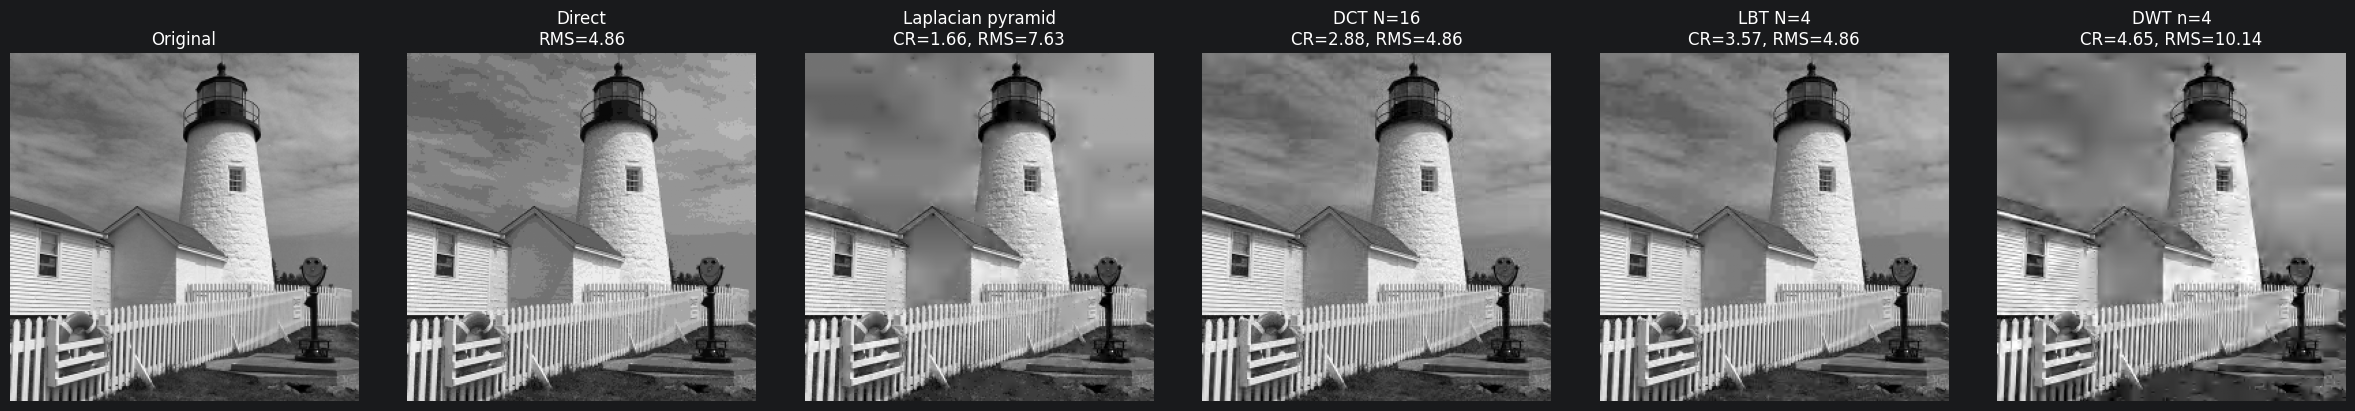

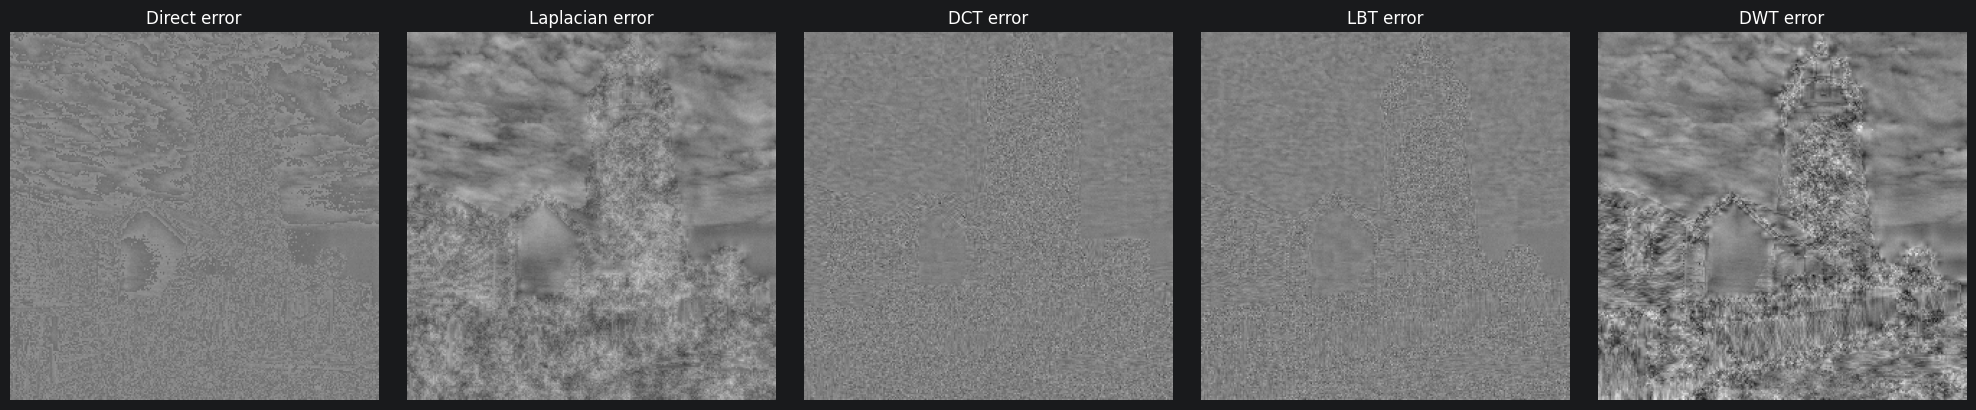

In [56]:
# ============================================================
# FINAL VISUAL COMPARISON:
# Original vs Direct vs Laplacian Pyramid vs DCT vs LBT vs DWT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize

from cued_sf2_lab.laplacian_pyramid import (
    bpp, quantise, rowdec, rowint
)
from cued_sf2_lab.dct import dct_ii, colxfm, regroup
from cued_sf2_lab.lbt import pot_ii
from cued_sf2_lab.dwt import dwt, idwt


# ------------------------------------------------------------
# General helpers
# ------------------------------------------------------------

def rms_error(A, B):
    return np.std(A - B)


def image_bits(img, step):
    return bpp(quantise(img, step)) * img.size


# Direct reference
step_direct = 17.0
X_direct = quantise(X, step_direct)
target_rms = rms_error(X, X_direct)
direct_bits = bpp(X_direct) * X.size

print(f"Direct reference RMS  = {target_rms:.4f}")
print(f"Direct reference bits = {direct_bits:.0f}")
print()


# ============================================================
# 1. Laplacian pyramid reconstruction
# ============================================================

h = np.array([1, 2, 1]) / 4
step_lp = 17.0


def dec2(X, h):
    return rowdec(rowdec(X, h).T, h).T


def int2(X, h):
    return rowint(rowint(X, 2 * h).T, 2 * h).T


def py4enc(X, h):
    X1 = dec2(X, h)
    Y0 = X - int2(X1, h)

    X2 = dec2(X1, h)
    Y1 = X1 - int2(X2, h)

    X3 = dec2(X2, h)
    Y2 = X2 - int2(X3, h)

    X4 = dec2(X3, h)
    Y3 = X3 - int2(X4, h)

    return Y0, Y1, Y2, Y3, X4


def py4dec(Y0, Y1, Y2, Y3, X4, h):
    Z3 = int2(X4, h) + Y3
    Z2 = int2(Z3, h) + Y2
    Z1 = int2(Z2, h) + Y1
    Z0 = int2(Z1, h) + Y0
    return Z0


Y0, Y1, Y2, Y3, X4 = py4enc(X, h)

Y0q = quantise(Y0, step_lp)
Y1q = quantise(Y1, step_lp)
Y2q = quantise(Y2, step_lp)
Y3q = quantise(Y3, step_lp)
X4q = quantise(X4, step_lp)

X_lp = py4dec(Y0q, Y1q, Y2q, Y3q, X4q, h)

lp_bits = (
    bpp(Y0q) * Y0q.size +
    bpp(Y1q) * Y1q.size +
    bpp(Y2q) * Y2q.size +
    bpp(Y3q) * Y3q.size +
    bpp(X4q) * X4q.size
)

lp_rms = rms_error(X, X_lp)
lp_cr = direct_bits / lp_bits


# ============================================================
# 2. Best DCT reconstruction
# Your report best DCT was N=16
# ============================================================

N_dct = 16
step_dct = 22.337

C = dct_ii(N_dct)
Y_dct = colxfm(colxfm(X, C).T, C).T
Yq_dct = quantise(Y_dct, step_dct)
X_dct = colxfm(colxfm(Yq_dct.T, C.T).T, C.T)

# Use your corrected dctbpp if already defined; otherwise define it.
def dctbpp_contiguous(Yr, N):
    total_bits = 0.0
    sub_h = Yr.shape[0] // N
    sub_w = Yr.shape[1] // N

    for r in range(N):
        for c in range(N):
            Ys = Yr[
                r * sub_h:(r + 1) * sub_h,
                c * sub_w:(c + 1) * sub_w
            ]
            total_bits += bpp(Ys) * Ys.size

    return total_bits


dct_bits = dctbpp_contiguous(regroup(Yq_dct, N_dct), N_dct)
dct_rms = rms_error(X, X_dct)
dct_cr = direct_bits / dct_bits


# ============================================================
# 3. Best LBT reconstruction
# Your report best LBT was N=4, s=sqrt(2)
# ============================================================

N_lbt = 4
s_lbt = np.sqrt(2)

C = dct_ii(N_lbt)
Pf, Pr = pot_ii(N_lbt, s_lbt)
t = np.s_[N_lbt // 2:-N_lbt // 2]


def lbt_reconstruct_for_step(step):
    Xp = X.copy()

    # Forward pre-filter
    Xp[t, :] = colxfm(Xp[t, :], Pf)
    Xp[:, t] = colxfm(Xp[:, t].T, Pf).T

    # DCT
    Y = colxfm(colxfm(Xp, C).T, C).T
    Yq = quantise(Y, step)

    # Inverse DCT
    Zp = colxfm(colxfm(Yq.T, C.T).T, C.T)

    # Post-filter
    Z = Zp.copy()
    Z[:, t] = colxfm(Z[:, t].T, Pr.T).T
    Z[t, :] = colxfm(Z[t, :], Pr.T)

    return Z, Yq


def lbt_objective(step):
    Z, _ = lbt_reconstruct_for_step(step)
    return abs(rms_error(X, Z) - target_rms)


res = scipy.optimize.minimize_scalar(
    lbt_objective,
    bounds=(0.01, 200),
    method="bounded",
    options={"xatol": 1e-3}
)

step_lbt = float(res.x)
X_lbt, Yq_lbt = lbt_reconstruct_for_step(step_lbt)

# For LBT block-size comparison, use dctbpp(Yr,16)-style coding blocks.
def dctbpp_blocks(Yr, coding_N=16):
    total_bits = 0.0

    for i in range(0, Yr.shape[0], coding_N):
        for j in range(0, Yr.shape[1], coding_N):
            block = Yr[i:i + coding_N, j:j + coding_N]
            total_bits += bpp(block) * block.size

    return total_bits


lbt_bits = dctbpp_blocks(regroup(Yq_lbt, N_lbt), 16)
lbt_rms = rms_error(X, X_lbt)
lbt_cr = direct_bits / lbt_bits


# ============================================================
# 4. DWT reconstruction
# Uses 4-level equal-step DWT as a simple comparison
# ============================================================

n_dwt = 4
step_dwt = 17.0


def nlevdwt(X, n):
    Y = X.copy()
    rows, cols = Y.shape

    for level in range(n):
        r = rows // (2 ** level)
        c = cols // (2 ** level)
        Y[:r, :c] = dwt(Y[:r, :c])

    return Y


def nlevidwt(Yq, n):
    Z = Yq.copy()
    rows, cols = Z.shape

    for level in range(n - 1, -1, -1):
        r = rows // (2 ** level)
        c = cols // (2 ** level)
        Z[:r, :c] = idwt(Z[:r, :c])

    return Z


def quantdwt_simple(Y, step):
    Yq = quantise(Y, step)
    return Yq


Y_dwt = nlevdwt(X, n_dwt)
Yq_dwt = quantdwt_simple(Y_dwt, step_dwt)
X_dwt = nlevidwt(Yq_dwt, n_dwt)

dwt_bits_simple = bpp(Yq_dwt) * Yq_dwt.size
dwt_rms = rms_error(X, X_dwt)
dwt_cr = direct_bits / dwt_bits_simple


# ============================================================
# Print comparison summary
# ============================================================

print("Method\t\tBits\t\tCR\t\tRMS")
print(f"Direct\t\t{direct_bits:.0f}\t\t1.000\t\t{target_rms:.4f}")
print(f"Laplacian\t{lp_bits:.0f}\t\t{lp_cr:.3f}\t\t{lp_rms:.4f}")
print(f"DCT N=16\t{dct_bits:.0f}\t\t{dct_cr:.3f}\t\t{dct_rms:.4f}")
print(f"LBT N=4\t\t{lbt_bits:.0f}\t\t{lbt_cr:.3f}\t\t{lbt_rms:.4f}")
print(f"DWT n=4\t\t{dwt_bits_simple:.0f}\t\t{dwt_cr:.3f}\t\t{dwt_rms:.4f}")


# ============================================================
# Figure 1: all reconstructions side by side
# ============================================================

vmin = np.min(X)
vmax = np.max(X)

fig, axes = plt.subplots(1, 6, figsize=(24, 4))

images = [
    (X, "Original"),
    (X_direct, f"Direct\nRMS={target_rms:.2f}"),
    (X_lp, f"Laplacian pyramid\nCR={lp_cr:.2f}, RMS={lp_rms:.2f}"),
    (X_dct, f"DCT N=16\nCR={dct_cr:.2f}, RMS={dct_rms:.2f}"),
    (X_lbt, f"LBT N=4\nCR={lbt_cr:.2f}, RMS={lbt_rms:.2f}"),
    (X_dwt, f"DWT n=4\nCR={dwt_cr:.2f}, RMS={dwt_rms:.2f}"),
]

for ax, (img, title) in zip(axes, images):
    ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Figure 2: error images side by side
# ============================================================

errors = [
    X - X_direct,
    X - X_lp,
    X - X_dct,
    X - X_lbt,
    X - X_dwt,
]

err_lim = max(np.max(np.abs(e)) for e in errors)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

error_images = [
    (errors[0], "Direct error"),
    (errors[1], "Laplacian error"),
    (errors[2], "DCT error"),
    (errors[3], "LBT error"),
    (errors[4], "DWT error"),
]

for ax, (err, title) in zip(axes, error_images):
    ax.imshow(err, cmap="gray", vmin=-err_lim, vmax=err_lim)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()